# **ΟΜΑΔΑ ΕΡΓΑΣΙΑΣ 3 - Ερώτηση 4**
*   Δημούδης Γεώργιος 5212
*   Στρούγγης Γεώργιος 5357

First few code blocks are copied from Exercise 2. We did everything on that one first, in case we had to test different things.

In [1]:
#Cells are expected to be run in order as seen. Thank you.

import pandas as pd
from sklearn.metrics import root_mean_squared_error
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

In [2]:
#is copy pasta from previous exercise.
train_df = pd.read_csv("data_train.csv", usecols=["uid", "mid", "rating"], on_bad_lines="skip")
test_df = pd.read_csv("data_test.csv", usecols=["uid", "mid", "rating"], on_bad_lines="skip")

ratings_train = train_df["rating"].tolist()
users_train = train_df["uid"].tolist()
movies_train = train_df["mid"].tolist()

sparse_data = sp.csr_matrix((ratings_train, (users_train, movies_train )), shape=(max(users_train)+1, max(movies_train )+1))
ratings_test = test_df["rating"].tolist()
users_test = test_df["uid"].tolist()
movies_test = test_df["mid"].tolist()
um_test = list(zip(users_test,movies_test))

In [16]:
#Rows refer to users, cols to movies. We grab the user row, we access its data and we take its mean.
def user_mean(R, u):
  return R.getrow(u).data.mean()

#We grab the columns that refer to the movie we are interested in.
#What we grab is a tuple with some .data associated with it.
#The tuples we grab are of the format (users,movies)
#We are interested in the users so we grab the first part.
#Without the nonzero part, we get a too many values to unpack error.
def item_users(R, m):
  rows, _ = R[:, m].nonzero()
  return rows

def build_user_graph(R, m):
	#builds the cosine similarities with the sklearn function
	#then grabs the biggest user id in the set, and starts the graph.
	cosine_sims = cosine_similarity(R)
	max_uid = np.arange(R.shape[0])[-1]
	G = nx.Graph()

	#grabs the cosine similarities for userU. Ranks them to grab the top ones.
  #We set the similarity for one's person as 0. Otherwise, theyd always be 1.
	for u in range(max_uid + 1):
		simsU = cosine_sims[u].copy()
		simsU[u] = 0
		top_m = np.argsort(simsU)[-m:][::-1]

    #Adds edge to graph if it doesnt already exist. We set the weight equal to the similarity with our user.
		for v in top_m:
			if not G.has_edge(u, v):
				G.add_edge(u, v, weight=simsU[v])

	return G

def compute_similarities(G):
	sims = {}
	for u in G.nodes():
		#personalization vector must include all nodes and sum to 1.
		#https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html:
		#The “personalization vector” consisting of a dictionary with a key some subset of graph nodes and personalization value each of those. At least one personalization value must be non-zero. If not specified, a nodes personalization value will be zero. By default, a uniform distribution is used.
		#We set the user node to 1, so as to start from that node always.
		#Alpha is by default 0.85. We could have skipped this, but we throw it in there for the tests.
		#The parameter alpha is not the jump probability as we have described in class, but the probability of following an out-link. The jump probability is 1-alpha.
		personalization = {v: 0 for v in G.nodes()}
		personalization[u] = 1
		ppr = nx.pagerank(
			G,
			alpha=0.4,
			personalization=personalization,
			weight="weight"
		)
		sims[u] = ppr
	return sims

def similar_users(sims, u, m_users, k):
	#Grabs the similarities of users m with regard to our user u.
	#It then arranges them and returns the best k users m and their similarities with u.
	sims = np.array([ppr_sims[u].get(v, 0) for v in m_users])

	if len(sims) > k:
		top_k_idx = np.argsort(sims)[-k:][::-1]
	else:
		top_k_idx = np.argsort(sims)[::-1]

	return [(m_users[i], sims[i]) for i in top_k_idx]

#k_similarities are the cosines similarities s(u,u')
#k_ratings are a kx1 array with of k users with ratings of some movie.
def compute_score(k_ratings, k_similarities):
  return np.sum(k_similarities * k_ratings) / np.sum(k_similarities)


In [13]:
#Basically the same structure as exercise 2. Not much to comment on.
#These results are based on alpha being 0.85, aka the default setting.

#We get the best result with k = 100 and m = 10
#Generally, the results we got were better as k got larger, with only 1 exception
#The exception was here:
#m=10, k=70, RMSE=0.9826277492304096
#m=10, k=80, RMSE=0.9825695482844039
#m=10, k=90, RMSE=0.9826357841246577
#Where k = 90 had a very small jump upwards, but its so small it might as well be a rounding error.
#For normal UCF, testing for larger ks was definitely slower, so we have somewhat of an increased speed here.
#Overall, we got the best results with the mean-centered UCF, which is also the most logically intuitive.
#The weights of the graphs being equal to the cosines are probably the reason we are seeing roughly the same results as the normal method.

def UCF_PPR(R, u, m, k, ppr_sims):
	people_who_rated_m = item_users(R, m)

	if len(people_who_rated_m) == 0:
		return user_mean(R, u)

	top_similar_users = similar_users(ppr_sims, u, people_who_rated_m, k)

	sim_users = [user for user, sim in top_similar_users]
	sim_values = np.array([sim for user, sim in top_similar_users])

	if np.all(sim_values == 0):
		return 0

	best_k_people_ratings = np.array([R[sim_user, m] for sim_user in sim_users])

	return compute_score(best_k_people_ratings, sim_values)

m_values = [3, 5, 10]
k_values = [1, 2, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = {}

for m in m_values:
	print(f"\nBuilding graph for m = {m}")
	G = build_user_graph(sparse_data, m)
	ppr_sims = compute_similarities(G)

	rmse_list = []

	for k in k_values:
		preds = []

		for (u, movie) in um_test:
			pred = UCF_PPR(sparse_data, u, movie, k, ppr_sims)
			preds.append(pred)

		rmse = root_mean_squared_error(ratings_test, preds)
		rmse_list.append(rmse)
		print(f"m={m}, k={k}, RMSE={rmse}")

	results[m] = rmse_list


Building graph for m = 3
m=3, k=1, RMSE=1.2468235018566496
m=3, k=2, RMSE=1.1143369345590595
m=3, k=3, RMSE=1.0718964645341351
m=3, k=5, RMSE=1.0388897714432315
m=3, k=10, RMSE=1.0164655678811556
m=3, k=20, RMSE=1.006673871769961
m=3, k=30, RMSE=1.0041717387102522
m=3, k=40, RMSE=1.0030871103118755
m=3, k=50, RMSE=1.0024886359840608
m=3, k=60, RMSE=1.0021395019386496
m=3, k=70, RMSE=1.0019147862441218
m=3, k=80, RMSE=1.001799331829166
m=3, k=90, RMSE=1.001710987462432
m=3, k=100, RMSE=1.001651674742154

Building graph for m = 5
m=5, k=1, RMSE=1.2395034670310845
m=5, k=2, RMSE=1.1050944342966047
m=5, k=3, RMSE=1.061098904550454
m=5, k=5, RMSE=1.0283420788928377
m=5, k=10, RMSE=1.0035824341407888
m=5, k=20, RMSE=0.9946642310286926
m=5, k=30, RMSE=0.9926731515409104
m=5, k=40, RMSE=0.9916323570527488
m=5, k=50, RMSE=0.991114156196473
m=5, k=60, RMSE=0.9908398928179213
m=5, k=70, RMSE=0.9906898201172709
m=5, k=80, RMSE=0.9906174043326536
m=5, k=90, RMSE=0.9905735114068829
m=5, k=100, RMSE

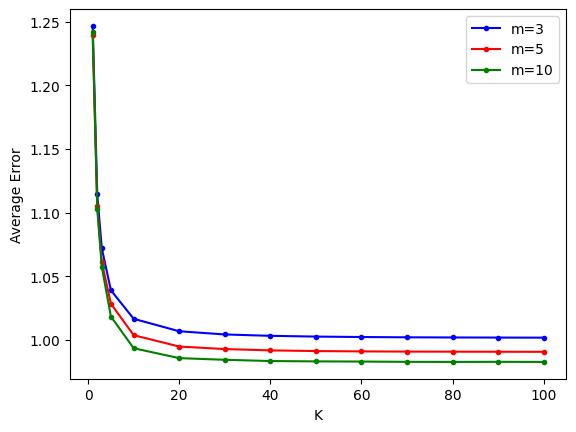

In [9]:
plt.plot(k_values, results[3], marker='.', color='blue', label="m=3")
plt.plot(k_values, results[5], marker='.', color='red', label="m=5")
plt.plot(k_values, results[10], marker='.', color='green', label="m=10")
plt.legend()
plt.xlabel('K')
plt.ylabel('Average Error')
plt.show()

# **BONUS**

In [15]:
#results for alpha = 0.1
#Noticably worse across the board.
#That is because we are going very far from the user U node.
#alpha being 0.1 means the jump probability is 0.9.
#Basically, it is the same issue as having too many ks in the previous exercise, where the more ks we had, the more diluted the suggestions were.
#Larger ks dont seem to dilute the results here nearly as much.
#That is probably because of the weights we have put in each node, when we did not have something similar in ex2.

m_values = [3, 5, 10]
k_values = [1, 2, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = {}

for m in m_values:
	print(f"\nBuilding graph for m = {m}")
	G = build_user_graph(sparse_data, m)
	ppr_sims = compute_similarities(G)

	rmse_list = []

	for k in k_values:
		preds = []

		for (u, movie) in um_test:
			pred = UCF_PPR(sparse_data, u, movie, k, ppr_sims)
			preds.append(pred)

		rmse = root_mean_squared_error(ratings_test, preds)
		rmse_list.append(rmse)
		print(f"m={m}, k={k}, RMSE={rmse}")

	results[m] = rmse_list


Building graph for m = 3
m=3, k=1, RMSE=1.246422418276436
m=3, k=2, RMSE=1.1493191344071356
m=3, k=3, RMSE=1.1248215341767571
m=3, k=5, RMSE=1.1136232667741839
m=3, k=10, RMSE=1.1082238323480083
m=3, k=20, RMSE=1.1067012468774922
m=3, k=30, RMSE=1.1064290371622134
m=3, k=40, RMSE=1.1063230059119316
m=3, k=50, RMSE=1.106276779491213
m=3, k=60, RMSE=1.1062642505725628
m=3, k=70, RMSE=1.106258454266503
m=3, k=80, RMSE=1.1062527555495099
m=3, k=90, RMSE=1.106247733091029
m=3, k=100, RMSE=1.1062424217177569

Building graph for m = 5
m=5, k=1, RMSE=1.235675460945178
m=5, k=2, RMSE=1.1276649890371202
m=5, k=3, RMSE=1.101416754035594
m=5, k=5, RMSE=1.0852081654883945
m=5, k=10, RMSE=1.0781871653453463
m=5, k=20, RMSE=1.0761769652444506
m=5, k=30, RMSE=1.0757121032016703
m=5, k=40, RMSE=1.0755469506083732
m=5, k=50, RMSE=1.075468437450958
m=5, k=60, RMSE=1.0754350901041778
m=5, k=70, RMSE=1.075415928152084
m=5, k=80, RMSE=1.075403989447223
m=5, k=90, RMSE=1.0753938963356688
m=5, k=100, RMSE=1.

In [17]:
#Results for alpha = 0.4
#It is still not quite as good as our original result across the board, but more similar.
#We dare say, if lower alphas increased the quality of the results, the default alpha in the function would probably not be 0.85.

m_values = [3, 5, 10]
k_values = [1, 2, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = {}

for m in m_values:
	print(f"\nBuilding graph for m = {m}")
	G = build_user_graph(sparse_data, m)
	ppr_sims = compute_similarities(G)

	rmse_list = []

	for k in k_values:
		preds = []

		for (u, movie) in um_test:
			pred = UCF_PPR(sparse_data, u, movie, k, ppr_sims)
			preds.append(pred)

		rmse = root_mean_squared_error(ratings_test, preds)
		rmse_list.append(rmse)
		print(f"m={m}, k={k}, RMSE={rmse}")

	results[m] = rmse_list


Building graph for m = 3
m=3, k=1, RMSE=1.2482262794790369
m=3, k=2, RMSE=1.1372480048420999
m=3, k=3, RMSE=1.1039772177297973
m=3, k=5, RMSE=1.0835732649171845
m=3, k=10, RMSE=1.069992225910633
m=3, k=20, RMSE=1.0647663642040062
m=3, k=30, RMSE=1.0634473525352026
m=3, k=40, RMSE=1.0628998787129877
m=3, k=50, RMSE=1.0626602735161617
m=3, k=60, RMSE=1.0625369185922267
m=3, k=70, RMSE=1.062467846612682
m=3, k=80, RMSE=1.0624188489279627
m=3, k=90, RMSE=1.062394458638952
m=3, k=100, RMSE=1.0623781424965058

Building graph for m = 5
m=5, k=1, RMSE=1.2445858125425016
m=5, k=2, RMSE=1.124261342406818
m=5, k=3, RMSE=1.0850549488955705
m=5, k=5, RMSE=1.060595280336678
m=5, k=10, RMSE=1.0460609213655072
m=5, k=20, RMSE=1.0399530394501022
m=5, k=30, RMSE=1.038315799157395
m=5, k=40, RMSE=1.0376015394194569
m=5, k=50, RMSE=1.0372503675790117
m=5, k=60, RMSE=1.0370947123530092
m=5, k=70, RMSE=1.0369776056489515
m=5, k=80, RMSE=1.036892260170418
m=5, k=90, RMSE=1.0368456509516997
m=5, k=100, RMSE=